In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split
import torch,time
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import models
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
# Define paths
base_dir = '/content/drive/MyDrive/train_aug_waste'
train_dir = f'{base_dir}/train'
test_dir = f'{base_dir}/test'
print(os.listdir(base_dir))
print(os.listdir(test_dir))

['train', 'test']
['none', 'metal', 'organic', 'paper', 'plastic']


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [5]:
#count no of images in each sub folder

import os

def count_images(folder):
    images = [
        img for img in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, img))
        and img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    print(f"{folder}: {len(images)} images")

# Check train and test folders
count_images('/content/drive/MyDrive/train_aug_waste/train/metal')
count_images(f'/content/drive/MyDrive/train_aug_waste/train/none')
count_images(f'/content/drive/MyDrive/train_aug_waste/train/organic')
count_images(f'/content/drive/MyDrive/train_aug_waste/train/plastic')
count_images(f'/content/drive/MyDrive/train_aug_waste/train/paper')

count_images('/content/drive/MyDrive/train_aug_waste/test/metal')
count_images(f'/content/drive/MyDrive/train_aug_waste/test/none')
count_images(f'/content/drive/MyDrive/train_aug_waste/test/organic')
count_images(f'/content/drive/MyDrive/train_aug_waste/test/plastic')
count_images(f'/content/drive/MyDrive/train_aug_waste/test/paper')

/content/drive/MyDrive/train_aug_waste/train/metal: 100 images
/content/drive/MyDrive/train_aug_waste/train/none: 112 images
/content/drive/MyDrive/train_aug_waste/train/organic: 21 images
/content/drive/MyDrive/train_aug_waste/train/plastic: 56 images
/content/drive/MyDrive/train_aug_waste/train/paper: 132 images
/content/drive/MyDrive/train_aug_waste/test/metal: 50 images
/content/drive/MyDrive/train_aug_waste/test/none: 50 images
/content/drive/MyDrive/train_aug_waste/test/organic: 50 images
/content/drive/MyDrive/train_aug_waste/test/plastic: 50 images
/content/drive/MyDrive/train_aug_waste/test/paper: 50 images


In [18]:
import os
import random
from PIL import Image
from torchvision import transforms

train_dir = "/content/drive/MyDrive/train_aug_waste/train"
target_size = 500

augment = transforms.Compose([
    transforms.RandomRotation(25),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0))
])

for cls in os.listdir(train_dir):

    class_path = os.path.join(train_dir, cls)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith((".jpg",".png",".jpeg"))]

    current_count = len(images)

    if current_count >= target_size:
        print(f"{cls} already has {current_count} images")
        continue

    needed = target_size - current_count

    print(f"{cls}: generating {needed} augmented images")

    for i in range(needed):

        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)

        image = Image.open(img_path).convert("RGB")
        aug_image = augment(image)

        new_name = f"aug_{i}_{img_name}"
        aug_image.save(os.path.join(class_path, new_name))


plastic: generating 381 augmented images
metal: generating 400 augmented images
organic: generating 479 augmented images
none: generating 388 augmented images
paper: generating 368 augmented images


In [19]:
#count no of images in each sub folder

import os

def count_images(folder):
    images = [
        img for img in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, img))
        and img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    print(f"{folder}: {len(images)} images")

# Check train and test folders
count_images('/content/drive/MyDrive/train_aug_waste/train/metal')
count_images(f'/content/drive/MyDrive/train_aug_waste/train/none')
count_images(f'/content/drive/MyDrive/train_aug_waste/train/organic')
count_images(f'/content/drive/MyDrive/train_aug_waste/train/plastic')
count_images(f'/content/drive/MyDrive/train_aug_waste/train/paper')

count_images('/content/drive/MyDrive/train_aug_waste/test/metal')
count_images(f'/content/drive/MyDrive/train_aug_waste/test/none')
count_images(f'/content/drive/MyDrive/train_aug_waste/test/organic')
count_images(f'/content/drive/MyDrive/train_aug_waste/test/plastic')
count_images(f'/content/drive/MyDrive/train_aug_waste/test/paper')

/content/drive/MyDrive/train_aug_waste/train/metal: 500 images
/content/drive/MyDrive/train_aug_waste/train/none: 500 images
/content/drive/MyDrive/train_aug_waste/train/organic: 500 images
/content/drive/MyDrive/train_aug_waste/train/plastic: 500 images
/content/drive/MyDrive/train_aug_waste/train/paper: 500 images
/content/drive/MyDrive/train_aug_waste/test/metal: 50 images
/content/drive/MyDrive/train_aug_waste/test/none: 50 images
/content/drive/MyDrive/train_aug_waste/test/organic: 50 images
/content/drive/MyDrive/train_aug_waste/test/plastic: 50 images
/content/drive/MyDrive/train_aug_waste/test/paper: 50 images


In [28]:
train_transform = transforms.Compose([
    # ========== Resize ==========
    transforms.Resize((224, 224)), # Resize all images to a consistent size
    # ========== Convert ==========
    transforms.ToTensor(),

    # ========== Normalize ==========
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



test_transform = transforms.Compose([
    # ========== Resize ==========
    transforms.Resize((224, 224)), # Resize all images to a consistent size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [29]:
train_dataset=datasets.ImageFolder(root='/content/drive/MyDrive/train_aug_waste/train',transform=train_transform)
test_dataset=datasets.ImageFolder(root='/content/drive/MyDrive/train_aug_waste/test',transform=test_transform)

In [30]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


In [32]:
#inspect first batch of data
img, label = next(iter(test_loader))
print(len(img))
print(img.shape)
print(label)

32
torch.Size([32, 3, 224, 224])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])


In [33]:
t = label.tolist()

counts = {i: t.count(i) for i in range(5)}
import json
print(json.dumps(counts, indent=4))


{
    "0": 32,
    "1": 0,
    "2": 0,
    "3": 0,
    "4": 0
}


In [34]:
# Build the model
class WasteClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(WasteClassifier, self).__init__()

        # Load pre-trained MobileNetV2
        self.mobilenet = models.mobilenet_v2(pretrained=True)

        # Freeze all layers initially
        for param in self.mobilenet.parameters():
            param.requires_grad = False

        # Replace classifier
        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.mobilenet(x)

    def unfreeze_last_layers(self, num_layers=30):
        # Unfreeze the last num_layers for fine-tuning
        layers = list(self.mobilenet.features.children())
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

# Initialize model
model = WasteClassifier(num_classes=5).to(device)
print(f"\nModel created with {sum(p.numel() for p in model.parameters())} parameters")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

# Loss and optimizer



Model created with 2586117 parameters
Trainable parameters: 362245


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# The model was already initialized in a previous cell (PjHe49kCqhle)
# model = model(num_classes=5).to(device) # This line caused the TypeError
print(model)

WasteClassifier(
  (mobilenet): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_s

In [36]:
# Loss and optimizer
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

scaler = torch.amp.GradScaler(device.type)

Train Dataset size: 2500
Test Dataset size: 250
Train Loader batches: 79
Test Loader batches: 8
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Min label: 0
Max label: 4
Unique labels: tensor([0, 1, 2, 3, 4])

Epoch 1 / 15

Train
Loss: 1.3687128613266764
Accuracy: 0.4544

Test
Loss: 0.9531634338200092
Accuracy: 0.748
Precision: 0.8321368359746191
Recall: 0.748
F1: 0.7550526429033974

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        50
           1       0.50      1.00      0.66        50
           2       1.00      0.60      0.75        50
           3       0.84      0.64      0.73        50
           4       0.82      0.56      0.67        50

    accuracy                           0.75       250
   macro avg       0.83      0.75      0.76       250
weighted avg       0.83      0.75      0.76       250


Saved Best Model
Time: 360.83256578445435

Epoch 2 / 15

Train
Loss: 0.8577

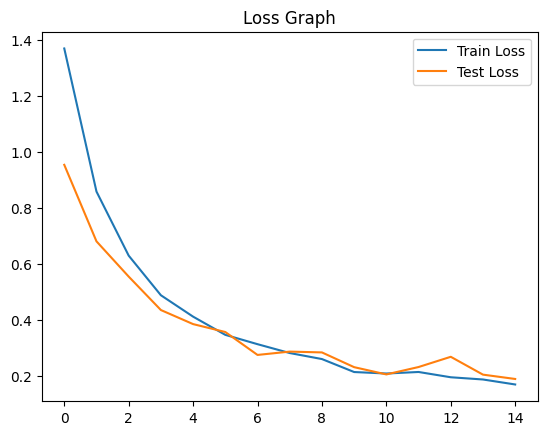

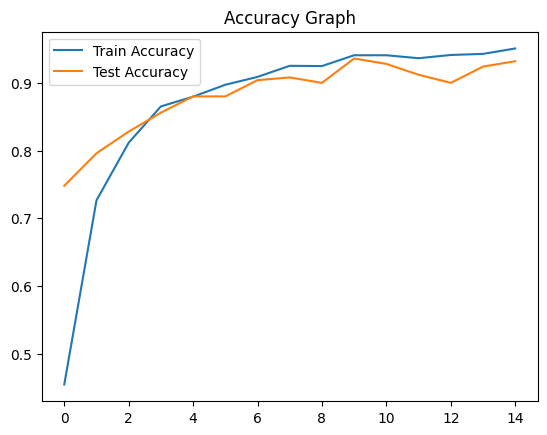

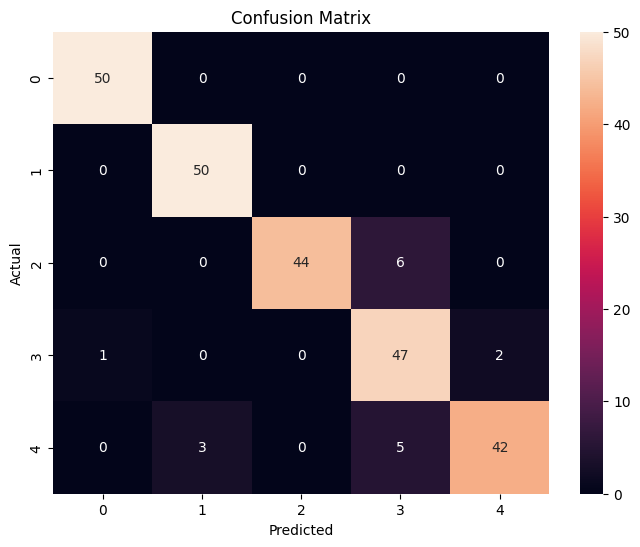

In [37]:
# ==========================
# ALL IN ONE CELL
# ==========================

import os
import time
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# --------------------------
# SETTINGS
# --------------------------

best_acc = 0.0
epochs = 15

save_dir = "/content/drive/MyDrive/train_aug_waste"
os.makedirs(save_dir, exist_ok=True)

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

# --------------------------
# CHECK DATASET
# --------------------------

print("Train Dataset size:", len(train_dataset))
print("Test Dataset size:", len(test_dataset))

print("Train Loader batches:", len(train_loader))
print("Test Loader batches:", len(test_loader))


# Inspect first batch

imgs, labels = next(iter(train_loader))

print("Batch shape:", imgs.shape)
print("Labels shape:", labels.shape)

print("Min label:", labels.min().item())
print("Max label:", labels.max().item())

print("Unique labels:", torch.unique(labels))


# --------------------------
# TRAIN FUNCTION
# --------------------------

def train_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs,1)

        correct += (preds==labels).sum().item()

        total += labels.size(0)


    avg_loss = total_loss / len(loader)

    acc = correct/total

    return avg_loss,acc


# --------------------------
# EVAL FUNCTION
# --------------------------

def eval_epoch(model, loader):

    model.eval()

    total_loss = 0

    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            loss=criterion(outputs,labels)

            total_loss+=loss.item()

            preds=torch.argmax(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    avg_loss=total_loss/len(loader)

    acc=accuracy_score(all_labels,all_preds)

    precision=precision_score(all_labels,all_preds,average='weighted')

    recall=recall_score(all_labels,all_preds,average='weighted')

    f1=f1_score(all_labels,all_preds,average='weighted')

    cm=confusion_matrix(all_labels,all_preds)

    return avg_loss,acc,precision,recall,f1,cm,all_labels,all_preds


# --------------------------
# TRAIN LOOP
# --------------------------

for epoch in range(epochs):

    t0=time.time()

    train_loss,train_acc=train_epoch(model,train_loader)

    test_loss,test_acc,precision,recall,f1,cm,y_true,y_pred=eval_epoch(model,test_loader)


    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)


    print("\n====================")

    print("Epoch",epoch+1,"/",epochs)

    print("\nTrain")

    print("Loss:",train_loss)
    print("Accuracy:",train_acc)


    print("\nTest")

    print("Loss:",test_loss)
    print("Accuracy:",test_acc)

    print("Precision:",precision)
    print("Recall:",recall)
    print("F1:",f1)


    print("\nClassification Report")

    print(classification_report(y_true,y_pred))


    if test_acc>best_acc:

        best_acc=test_acc

        torch.save(
            model.state_dict(),
            os.path.join(save_dir,
            "mobilenet_best.pth")
        )

        print("\nSaved Best Model")


    print("Time:",time.time()-t0)



# --------------------------
# PLOTS
# --------------------------

print("\nTraining Finished")


# Loss graph

plt.figure()

plt.plot(train_losses,label="Train Loss")
plt.plot(test_losses,label="Test Loss")

plt.legend()

plt.title("Loss Graph")

plt.show()



# Accuracy graph

plt.figure()

plt.plot(train_accuracies,label="Train Accuracy")
plt.plot(test_accuracies,label="Test Accuracy")

plt.legend()

plt.title("Accuracy Graph")

plt.show()



# Confusion Matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [38]:
import torch
from torchvision import models
import torch.nn as nn

num_classes = 4  # change to your actual number of classes

# The 'model' object is already correctly initialized in previous cells
# using the 'get_model' function, which sets its classifier architecture.
# Redefining the classifier here would create an architectural mismatch
# with the saved state_dict.
# Therefore, the lines that redefine the classifier have been removed.

# Step 2: Load saved weights
state_dict_path = "/content/drive/MyDrive/train_aug_waste/mobilenet_best.pth"
model.load_state_dict(torch.load(state_dict_path, map_location="cpu"))
# Step 3: Switch to evaluation mode
model.eval()

torch.save(model, "/content/drive/MyDrive/train_aug_waste/mobilenet_best.pth")

📊 Evaluation Metrics
Accuracy:  0.9360
Precision: 0.9374
Recall:    0.9360
F1-score:  0.9344

Detailed classification report:
              precision    recall  f1-score   support

       metal       0.94      1.00      0.97        50
        none       0.93      1.00      0.96        50
     organic       0.98      0.96      0.97        50
       paper       0.89      0.94      0.91        50
     plastic       0.95      0.78      0.86        50

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.93       250
weighted avg       0.94      0.94      0.93       250



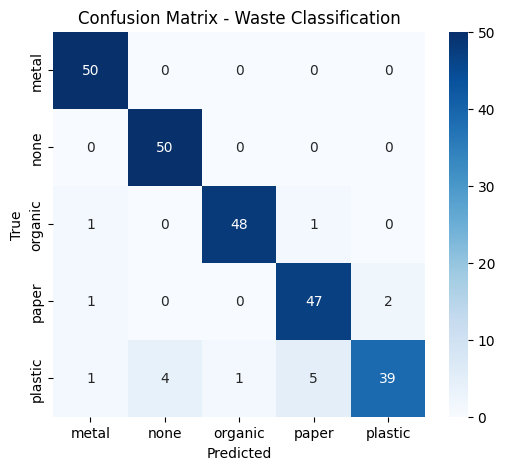

In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------
# Load best saved model
# ----------------------------
# The file "newer_waste_new_mobilenetv2_best.pth" was saved using `torch.save(model, ...)` in the previous cell,
# which saves the entire model object. To correctly load it, we should assign the output of `torch.load` directly
# to the 'model' variable, and set `weights_only=False` to allow loading of the full model object.
model = torch.load("/content/drive/MyDrive/train_aug_waste/mobilenet_best.pth", map_location=device, weights_only=False)
model.eval() # Ensure the model is in evaluation mode

# ----------------------------
# Evaluate on Test Set
# ----------------------------
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

# ----------------------------
# Metrics
# ----------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("📊 Evaluation Metrics")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nDetailed classification report:")
class_names = test_dataset.classes
print(classification_report(y_true, y_pred, target_names=class_names))

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Waste Classification")
plt.show()